In [7]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import os
import json

import torch

In [8]:
def calculate_rolling_average(
        data: np.ndarray,
        window_size: int = 10
) -> np.ndarray:
    return np.convolve(np.pad(data, pad_width=int(window_size/2), mode="reflect"), np.ones(window_size)/window_size, mode='valid')[:-1]

In [9]:
def calculate_f(latitude: float):
    omega = 2 * np.pi / 24 / 60 / 60
    return 2 * omega * np.sin(np.pi * latitude / 180)

In [10]:
def calculate_T(latitude: float):
    return 2 * np.pi / calculate_f(latitude)

In [37]:
data_directory = '../m_star_dataset'
dataset_name = 'ePBL_paper_validation_2283_corrected'

bl_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_bl_smoothed.nc'))
M_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_M.nc'))
uv_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_ekman_filtered_uv_surface.nc'))
# u_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_u_surf.nc'))
# v_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_v_surf.nc'))
SS_bl_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_SS_bl.nc'))
NN_bl_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_NN_bl.nc'))
Rig_bl_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_Rig_bl.nc'))

with open(os.path.join(data_directory, f'{dataset_name}_training_set_cases.json'), 'r') as file:
    gotm_case_dict = json.load(file)

In [38]:
rho0 = 1027
g = 9.81
alpha = 2e-4
cp = 4e3

heat_fluxes = np.array([case['heat_flux'] for case in gotm_case_dict.values()])
coriolis_freqs = np.array([calculate_f(case['lat']) for case in gotm_case_dict.values()])
u_stars = np.array([(case['tx'] / rho0) ** 0.5 for case in gotm_case_dict.values()])
taus = np.array([case['tx'] for case in gotm_case_dict.values()])

Bs = g * alpha * heat_fluxes / (rho0 * cp)

n_cases, t_timesteps = bl_data.bl.values[:,2:].shape

bls = bl_data.bl[:,2:].values.flatten()
Ms = M_data.M.values[:,2:].flatten()
us = uv_data.u_i.values[:,2:].flatten()
vs = uv_data.v_i.values[:,2:].flatten()
# us = u_data.u_surf.values[:,2:].flatten()
# vs = v_data.v_surf.values[:,2:].flatten()
SS_bl = np.log10(SS_bl_data.SS_bl.values[:,2:].flatten())
NN_bl = np.log10(NN_bl_data.NN_bl.values[:,2:].flatten())
Rig_bl = np.log10(Rig_bl_data.Rig_bl.values[:,2:].flatten())
Rig_bl = np.where(np.isnan(Rig_bl), 1., Rig_bl)

coriolis_freqs = np.repeat(coriolis_freqs, t_timesteps)
u_stars = np.repeat(u_stars, t_timesteps)
taus = np.repeat(taus, t_timesteps)
Bs = np.repeat(Bs, t_timesteps)

surface_magnitudes = taus*np.sqrt(us**2+vs**2)
surface_angles = np.arccos(us*taus/(np.sqrt(us**2+vs**2)*taus))
surface_ekin_input = abs(surface_magnitudes*np.cos(surface_angles))

/tmp/ipykernel_4049373/1226758063.py:1: RuntimeWarning: invalid value encountered in log10
  plt.hist(np.log10(SS_bl), color="black", ec="white")
/home/mm6851/miniconda3/envs/scientific_python/lib/python3.13/site-packages/matplotlib/axes/_axes.py:7104: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
/home/mm6851/miniconda3/envs/scientific_python/lib/python3.13/site-packages/matplotlib/axes/_axes.py:7105: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))


ValueError: autodetected range of [nan, nan] is not finite

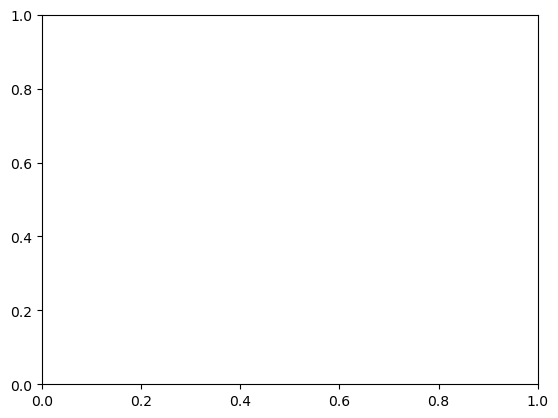

In [34]:
plt.hist(np.log10(SS_bl), color="black", ec="white")

(array([  3555.,  25971., 171490., 390709., 406418., 215835., 115521.,
         46196.,  16541.,   4204.]),
 array([ 1.        ,  2.87484177,  4.74968353,  6.6245253 ,  8.49936706,
        10.37420883, 12.24905059, 14.12389236, 15.99873413, 17.87357589,
        19.74841766]),
 <BarContainer object of 10 artists>)

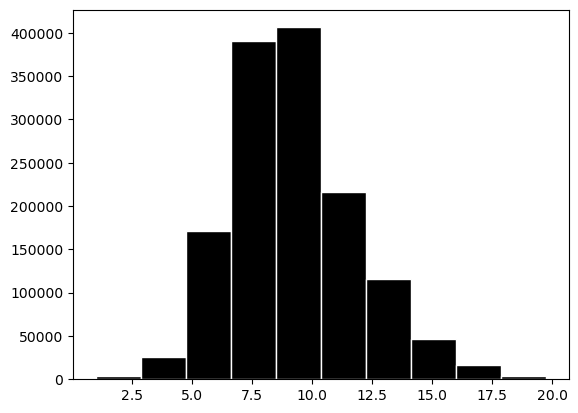

In [31]:
plt.hist(np.sqrt(bls_im1), color="black", ec="white")

(array([ 36879.,  86747.,  42910., 108184., 140572., 187794., 273914.,
        359982., 149140.,  10318.]),
 array([-2.28229657, -2.04875893, -1.81522128, -1.58168364, -1.348146  ,
        -1.11460835, -0.88107071, -0.64753306, -0.41399542, -0.18045778,
         0.05307987]),
 <BarContainer object of 10 artists>)

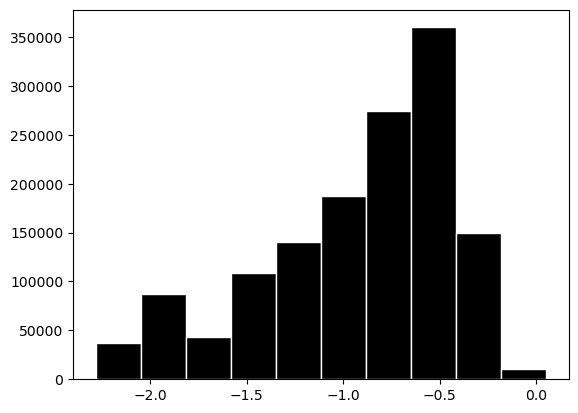

In [32]:
plt.hist(np.log10(surface_magnitudes), color="black", ec="white")

(array([2.00000e+00, 5.00000e+00, 2.50000e+01, 7.40000e+01, 4.87000e+02,
        2.35620e+04, 1.50777e+05, 2.96441e+05, 6.27123e+05, 2.97944e+05]),
 array([-5.53261129, -4.98149942, -4.43038755, -3.87927567, -3.3281638 ,
        -2.77705193, -2.22594006, -1.67482819, -1.12371632, -0.57260444,
        -0.02149257]),
 <BarContainer object of 10 artists>)

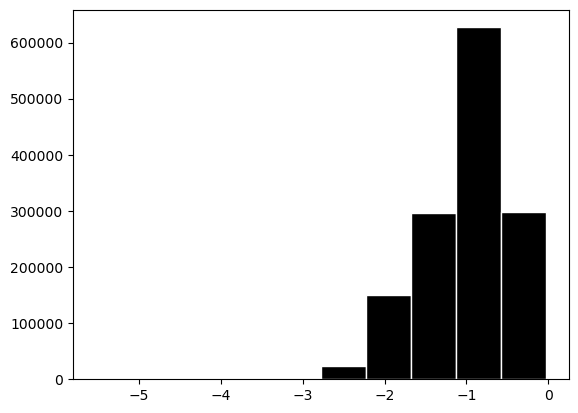

In [33]:
plt.hist(np.log10(surface_ekin_input), color="black", ec="white")

(array([2.50000e+01, 3.49000e+02, 1.89700e+03, 5.80200e+03, 2.05180e+04,
        1.39875e+05, 4.34885e+05, 2.78917e+05, 3.86605e+05, 1.27567e+05]),
 array([-10.05546722,  -9.29047874,  -8.52549027,  -7.76050179,
         -6.99551332,  -6.23052485,  -5.46553637,  -4.7005479 ,
         -3.93555943,  -3.17057095,  -2.40558248]),
 <BarContainer object of 10 artists>)

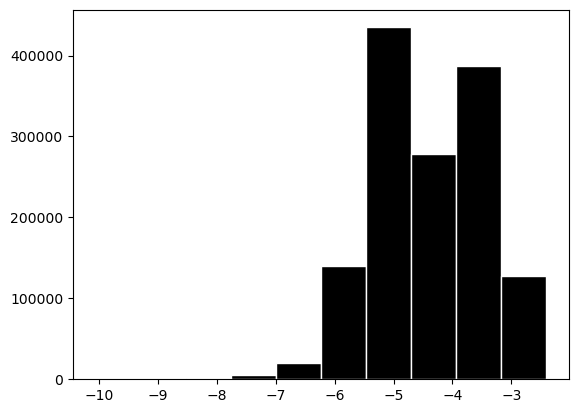

In [34]:
plt.hist(np.log10(SS_bl), color="black", ec="white")

(array([  1896.,   5806.,  60743., 238659., 349855., 385429., 238636.,
         83749.,  27604.,   4063.]),
 array([0.14990901, 0.26245902, 0.37500903, 0.48755903, 0.60010904,
        0.71265905, 0.82520905, 0.93775906, 1.05030907, 1.16285907,
        1.27540908]),
 <BarContainer object of 10 artists>)

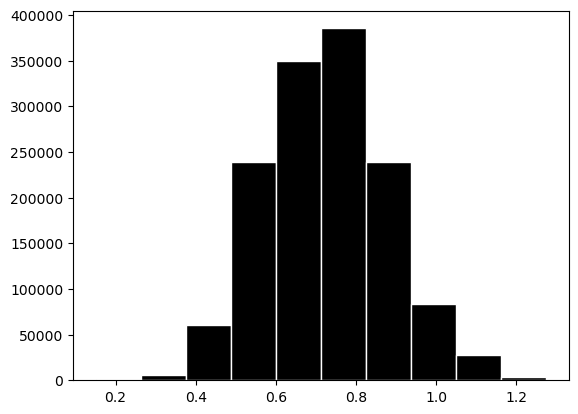

In [35]:
plt.hist(np.sqrt(surface_angles), color="black", ec="white")

In [36]:
# transformations
sqrt_bls = np.sqrt(bls)
sqrt_bls_im1 = np.sqrt(bls_im1)
log_NN_bl = np.log10(NN_bl)
log_SS_bl = np.log10(SS_bl)
sqrt_surface_angles = np.sqrt(surface_angles)
log_surface_ekin_input = np.log10(surface_ekin_input)
log_surface_magnitudes = np.log10(surface_magnitudes)

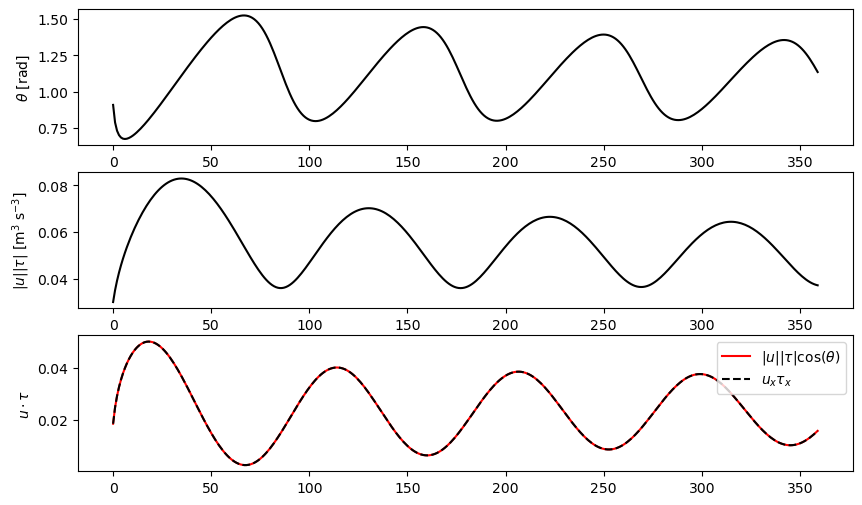

In [31]:
fig, ax = plt.subplots(3,1,figsize=(10,6))

ax[0].set_ylabel(r"$\theta$ [rad]")
ax[0].plot(surface_angles[0:360], color="black")
ax[1].set_ylabel(r"$|u||\tau|$ [m$^3$ s$^{-3}$]")
ax[1].plot(surface_magnitudes[0:360], color="black")
ax[2].set_ylabel(r"$u \cdot \tau$")
ax[2].plot(surface_ekin_input[0:360], color="red", label=r"$|u||\tau|\cos(\theta)$")
ax[2].plot(us[0:360]*taus[0:360], color="black", linestyle="dashed", label=r"$u_x\tau_x$")
ax[2].legend()

In [39]:
torch_dataset_name = f"{dataset_name}_dataset_M_target_bl_smoothed_log_NN_SS_Rig_ekman_filtered_uv.pt"
# dataset = torch.tensor(np.array([
#     coriolis_freqs, u_stars, sqrt_bls, Bs, log_surface_magnitudes, sqrt_surface_angles, log_surface_ekin_input, sqrt_bls_im1,
#     us_bl, vs_bl, log_SS_bl, log_NN_bl, 
#     Ms
# ]))
dataset = torch.tensor(np.array([
    coriolis_freqs, u_stars, bls, Bs, surface_magnitudes, surface_angles, surface_ekin_input, SS_bl, NN_bl, Rig_bl, Ms
]))
torch.save(dataset, os.path.join(data_directory, torch_dataset_name))

In [ ]:
t_timesteps*n_cases

1402920

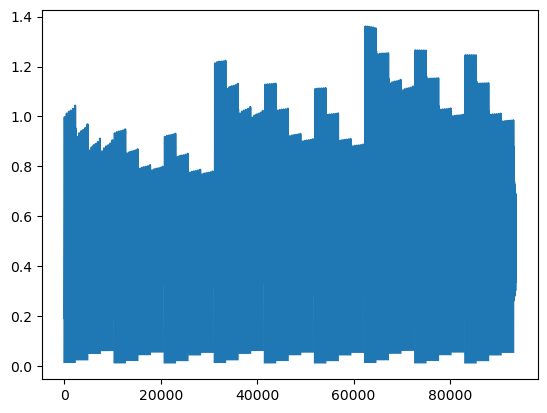

In [52]:
plt.plot(dataset[5,:])